In [12]:
!pip install catboost lightgbm xgboost optuna -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.base import clone
from sklearn.linear_model import ElasticNet

from catboost import CatBoostRegressor
import lightgbm as lgb
import xgboost as xgb
import optuna

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")

In [13]:
df = pd.read_csv("/content/drive/MyDrive/datasets/crop_yield_data.csv")

target = "yield"

cat_cols = ["soil_type", "crop_name", "water_supply", "fertilizer_usage"]
num_cols = ["temperature", "rainfall", "soil_ph"]

print("Shape:", df.shape)
df.head()

Shape: (10000, 11)


,soil_type,crop_name,water_supply,temperature,rainfall,soil_ph,humidity,sunlight,wind_speed,fertilizer_usage,yield
0,Silt,Cotton,Irrigated,23.6,157.8,7.00,75.4,6.1,14.6,High,10.87
1,Silt,Cotton,Irrigated,28.1,127.9,6.43,88.7,7.4,2.3,Low,9.65
2,Clay,Rice,Irrigated,27.6,188.3,6.08,46.1,9.0,1.5,Medium,10.44
3,Loam,Wheat,Irrigated,20.2,92.7,6.88,59.8,11.6,11.2,Medium,8.88
4,Clay,Sugarcane,Rainfed,35.1,218.5,5.36,67.1,6.8,12.2,High,63.67


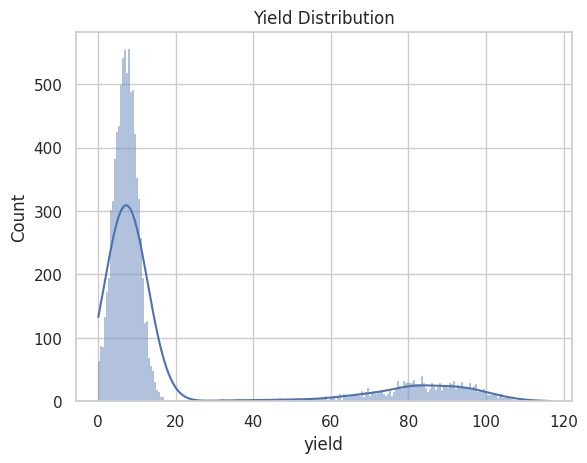

In [14]:
plt.figure()
sns.histplot(df[target], kde=True)
plt.title("Yield Distribution")
plt.show()

In [15]:
df["temp_rain"] = df["temperature"] * df["rainfall"]
df["ph_sq"] = df["soil_ph"] ** 2
df["rain_log"] = np.log1p(df["rainfall"])
df["temp_sq"] = df["temperature"] ** 2

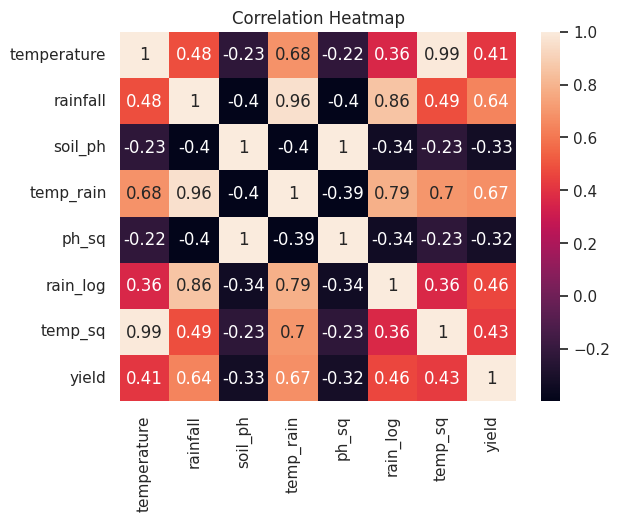

In [16]:
plt.figure()

corr_cols = num_cols + ["temp_rain", "ph_sq", "rain_log", "temp_sq", target]
sns.heatmap(df[corr_cols].corr(), annot=True)

plt.title("Correlation Heatmap")
plt.show()

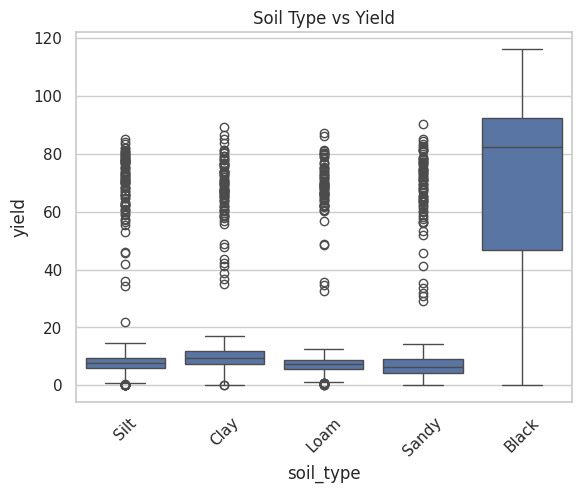

In [17]:
plt.figure()
sns.boxplot(x="soil_type", y="yield", data=df)
plt.title("Soil Type vs Yield")
plt.xticks(rotation=45)
plt.show()

In [18]:
features = cat_cols + num_cols + ["temp_rain", "ph_sq", "rain_log", "temp_sq"]

X = df[features].copy()
y = df[target]

y_log = np.log1p(y)

In [19]:
X_encoded = X.copy()
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [21]:
def lgb_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "max_depth": trial.suggest_int("max_depth", 4, 8),
        "num_leaves": trial.suggest_int("num_leaves", 20, 100),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 30),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 2),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 2),
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1
    }
    scores = []
    kf = KFold(n_splits=3, shuffle=True, random_state=42)  # reduce CV folds
    for train_idx, val_idx in kf.split(X_encoded):
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_encoded.iloc[train_idx],
            y_log.iloc[train_idx],
            eval_set=[(X_encoded.iloc[val_idx], y_log.iloc[val_idx])],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(30, verbose=False)]  # faster stopping
        )
        preds = np.expm1(model.predict(X_encoded.iloc[val_idx]))
        scores.append(r2_score(y.iloc[val_idx], preds))
    return np.mean(scores)

In [43]:
X_catboost = X.copy()
for col in cat_cols:
    X_catboost[col] = X_catboost[col].astype(str)

In [45]:
# Reduce CatBoost/XGB/LGBM iterations
cat_model = CatBoostRegressor(
    iterations=800, depth=8, learning_rate=0.03,
    loss_function='RMSE', random_state=42,
    verbose=False, task_type='CPU'
)
cat_model.fit(X_catboost, y_log, cat_features=cat_cols)

xgb_model = xgb.XGBRegressor(n_estimators=800, max_depth=8,
                             learning_rate=0.03, subsample=0.8,
                             colsample_bytree=0.8, tree_method='hist',
                             random_state=42)

# Use 3-fold CV for stacking instead of 5
kf = KFold(n_splits=3, shuffle=True, random_state=42)

# Optionally, train base models on full data for prediction to avoid repeated CV inside stacking
cat_model.fit(X, y_log, cat_features=cat_cols, verbose=False)
lgb_model.fit(X_encoded, y_log)
xgb_model.fit(X_encoded, y_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

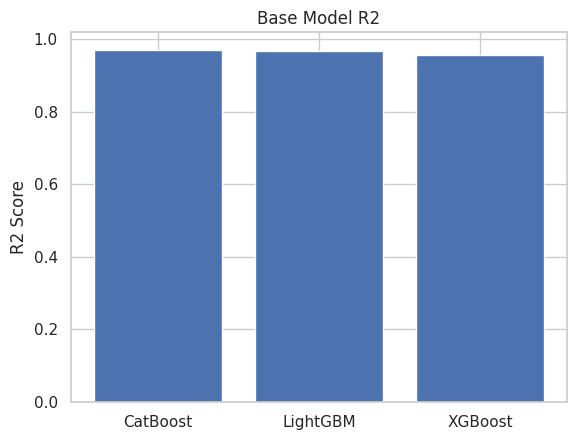

In [46]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import numpy as np

model_map = {
    "CatBoost": cat_model,
    "LightGBM": lgb_model,
    "XGBoost": xgb_model
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = {}

for name, model in model_map.items():
    meta_preds = np.zeros(len(X))  # store fold predictions

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        X_tr_enc, X_val_enc = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
        y_tr, y_val = y_log.iloc[train_idx], y.iloc[val_idx]

        if name == "CatBoost":
            model.fit(X_tr, y_tr, cat_features=cat_cols, verbose=False)
            preds = np.expm1(model.predict(X_val))
        else:
            model.fit(X_tr_enc, y_tr)
            preds = np.expm1(model.predict(X_val_enc))

        meta_preds[val_idx] = preds

    r2_scores[name] = r2_score(y, meta_preds)

# Plot
import matplotlib.pyplot as plt
plt.bar(r2_scores.keys(), r2_scores.values())
plt.ylabel("R2 Score")
plt.title("Base Model R2")
plt.show()

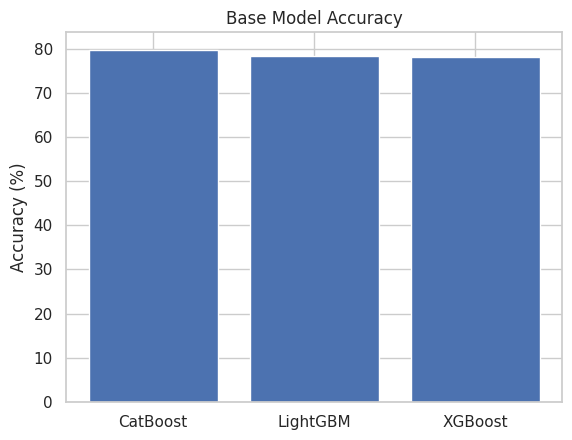

In [25]:
accuracies = {}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in zip(model_names, [cat_model, lgb_model, xgb_model]):
    preds = np.zeros(len(y))

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        X_tr_enc, X_val_enc = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
        y_tr = y_log.iloc[train_idx]

        if name == "CatBoost":
            model.fit(X_tr, y_tr, cat_features=cat_cols, verbose=False)
            preds[val_idx] = np.expm1(model.predict(X_val))
        else:
            model.fit(X_tr_enc, y_tr)
            preds[val_idx] = np.expm1(model.predict(X_val_enc))

    mape = np.mean(np.abs((y - preds) / (y + 1e-6))) * 100
    accuracies[name] = 100 - mape

# Plot
import matplotlib.pyplot as plt
plt.figure()
plt.bar(accuracies.keys(), accuracies.values())
plt.ylabel("Accuracy (%)")
plt.title("Base Model Accuracy")
plt.show()

In [26]:
# Initialize meta feature array
meta_features = np.zeros((len(X), 3))

# CatBoost
cat_model.fit(X, y_log, cat_features=cat_cols, verbose=False)
meta_features[:, 0] = np.expm1(cat_model.predict(X))

# LightGBM
lgb_model.fit(X_encoded, y_log)
meta_features[:, 1] = np.expm1(lgb_model.predict(X_encoded))

# XGBoost
xgb_model.fit(X_encoded, y_log)
meta_features[:, 2] = np.expm1(xgb_model.predict(X_encoded))

# Fit meta-model
meta_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
meta_model.fit(meta_features, y)

# Predictions
stack_preds = meta_model.predict(meta_features)

In [27]:
meta_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
meta_model.fit(meta_features, y)

stack_preds = meta_model.predict(meta_features)

r2 = r2_score(y, stack_preds)
mae = mean_absolute_error(y, stack_preds)
mape = np.mean(np.abs((y - stack_preds) / (y + 1e-6))) * 100
accuracy = 100 - mape

print("R2:", r2)
print("MAE:", mae)
print("Accuracy:", accuracy)

R2: 0.9969641329629668
MAE: 0.8029259247910168
Accuracy: 94.42813272399368


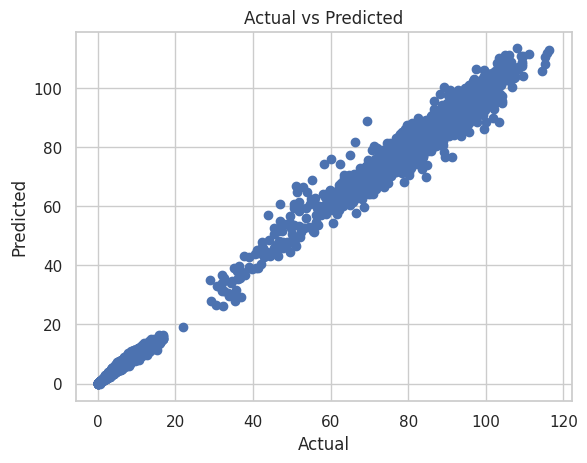

In [28]:
plt.figure()
plt.scatter(y, stack_preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

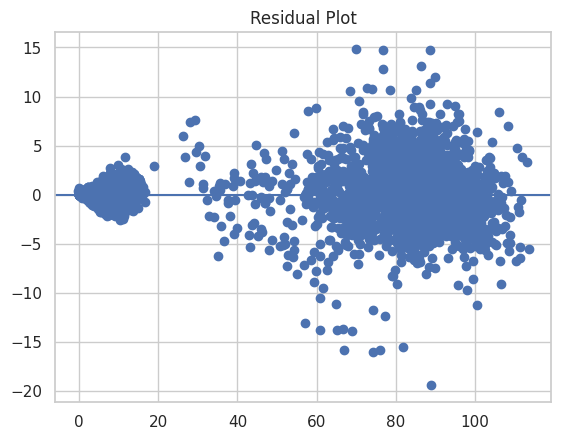

In [29]:
residuals = y - stack_preds

plt.figure()
plt.scatter(stack_preds, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.show()

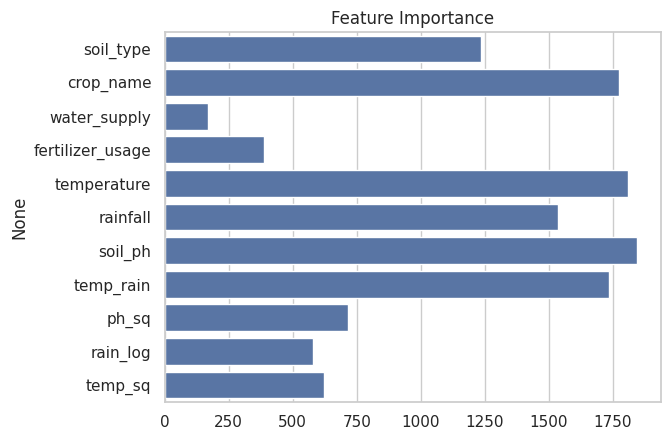

In [30]:
lgb_model.fit(X_encoded, y_log)

plt.figure()
sns.barplot(x=lgb_model.feature_importances_, y=X_encoded.columns)
plt.title("Feature Importance")
plt.show()

In [48]:
cat_model.fit(X, y_log, cat_features=cat_cols, verbose=False)
lgb_model.fit(X_encoded, y_log)
xgb_model.fit(X_encoded, y_log)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=800,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
def predict_yield(input_df):
    df = input_df.copy()

    # 1. Feature engineering (Must be done before reordering)
    df["temp_rain"] = df["temperature"] * df["rainfall"]
    df["ph_sq"] = df["soil_ph"] ** 2
    df["rain_log"] = np.log1p(df["rainfall"])
    df["temp_sq"] = df["temperature"] ** 2

    # 2. Match the exact feature order used during training
    # This is a common source of silent errors!
    df = df[features]

    # 3. Prepare CatBoost DataFrame
    df_cat = df.copy()
    for col in cat_cols:
        # Force conversion to string and strip any trailing .0 from floats
        df_cat[col] = df_cat[col].astype(float).astype(int).astype(str) if df_cat[col].dtype != object else df_cat[col].astype(str)

    # 4. Label encode for LGBM/XGB
    df_enc = df.copy()
    for col in cat_cols:
        le = label_encoders[col]
        # Handle unseen labels by mapping to a default if necessary
        df_enc[col] = df_enc[col].apply(lambda x: le.transform([str(x)])[0] if str(x) in le.classes_ else -1)

    # 5. Base predictions
    p1 = np.expm1(cat_model.predict(df_cat))
    p2 = np.expm1(lgb_model.predict(df_enc))
    p3 = np.expm1(xgb_model.predict(df_enc))

    # 6. Meta-model prediction
    # Reshape to (1, 3) for a single sample prediction
    meta_input = np.array([[p1[0], p2[0], p3[0]]])
    return meta_model.predict(meta_input)[0]

In [54]:
# Test prediction using sample input data

sample = pd.DataFrame({
    "soil_type": ["Loamy"],
    "crop_name": ["Tomato"],
    "water_supply": 20,
    "temperature": 28.0,
    "rainfall": 280.0,
    "soil_ph": 6.8,
    "fertilizer_usage": 40
})


In [59]:
yield_pred_ha = predict_yield(sample)
yield_pred_acre = yield_pred_ha / 2.47105

print(f"Predicted Yield: {yield_pred_ha:.2f} Tons/Ha")
print(f"Predicted Yield: {yield_pred_acre:.2f} Tons/Acre")

Predicted Yield: 3.38 Tons/Ha
Predicted Yield: 1.37 Tons/Acre
